# SEITR Network Simulation with Optimal Control — Refactored

This notebook implements the network-aware optimal control pipeline for the SEITR
epidemic model. Each experiment can be run independently using `run_experiment()`.

**Key improvements over the original codebase:**
- C++ simulation kernel (Rcpp): replaces the pure-R inner loop for ~50-200x speedup
- Soft deletion scheme: avoids costly igraph vertex reindexing
- Chapter 1-consistent edge addition: ER (fixed-count), BA (mean-degree), WS (BFS nearest-neighbor)
- Flexible `run_experiment()`: can run optimization, forward simulation, or both
- ODE warm-start for multi-start optimization
- Native support for ER, BA, and WS networks in the C++ kernel

The probabilistic model and algorithm are **identical** to the published description
(Algorithm 1). Only the implementation language and data structures differ.

## Setup

Compile the C++ kernel and source all R helper files.

In [1]:
# ============================================================================
# SETUP: Compile C++ kernel, source helper files, set display options
# ============================================================================

library(Rcpp)
library(ggplot2)
library(gridExtra)
library(parallel)
library(optimParallel)

options(repr.plot.width = 10, repr.plot.height = 5)

# Compile C++ simulation kernel (cached by Rcpp after first compilation)
cat('Compiling C++ kernel...\n')
Rcpp::sourceCpp('src/seitr_kernel.cpp')
cat('C++ kernel ready.\n')

# Source R helper files
source('src/utils.R')
source('src/ode_control.R')
source('src/experiment.R')
source('src/plotting.R')

cat('All helpers loaded.\n')

Warning message:
“package ‘Rcpp’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘gridExtra’ was built under R version 4.3.3”
Warning message:
“package ‘optimParallel’ was built under R version 4.3.3”


Compiling C++ kernel...
C++ kernel ready.
All helpers loaded.


## Shared Parameters

Epidemiological and control parameters fixed across all experiments.

In [3]:
# ============================================================================
# PARAMETERS (fixed across all experiments, matching the paper)
# ============================================================================

Lambda  <- 0.4;    beta1   <- 0.9;    beta2  <- 0.059;   beta3  <- 0.2
alpha1  <- 0.03;   alpha2  <- 0.055;  delta_I <- 0.03;   delta_T <- 0.03
mu      <- 0.02

w1   <- 0.2        # Quadratic weight on control cost
zeta <- 1          # Upper bound: 0 <= u(t) <= zeta
t_max  <- 100;  dt <- 1;  n <- 100
init_S <- 50; init_E <- 25; init_I <- 15; init_T <- 5; init_R <- 5

# Shared arguments list (avoids repetition in run_experiment calls)
shared_args <- list(
  Lambda = Lambda, beta1 = beta1, beta2 = beta2, beta3 = beta3,
  alpha1 = alpha1, alpha2 = alpha2, delta_I = delta_I, delta_T = delta_T,
  mu = mu, w1 = w1, zeta = zeta, t_max = t_max, dt = dt,
  init_S = init_S, init_E = init_E, init_I = init_I,
  init_T = init_T, init_R = init_R,
  cpp_path = 'src/seitr_kernel.cpp'
)

n_cores <- max(1, parallel::detectCores() - 2)
cat('Using', n_cores, 'of', parallel::detectCores(), 'cores\n')

Using 16 of 18 cores


## ODE Optimal Control (Mean-Field Reference)

Solve the deterministic ODE using the forward-backward sweep method.
The solution serves as a benchmark and as a warm-start for the network optimizer.

In [4]:
# ============================================================================
# ODE OPTIMAL CONTROL (forward-backward sweep)
# ============================================================================

ode_sol <- solve_ode_optimal_control(
  Lambda = Lambda, beta1 = beta1, beta2 = beta2, beta3 = beta3,
  alpha1 = alpha1, alpha2 = alpha2, delta_I = delta_I, delta_T = delta_T,
  mu = mu, w1 = w1, zeta = zeta,
  h = 0.01, t_max = t_max,
  S0 = init_S, E0 = init_E, I0 = init_I, T0 = init_T, R0 = init_R
)

# ODE objective via Simpson's rule
n_ode <- length(ode_sol$time)
if (n_ode %% 2 == 0) n_ode <- n_ode - 1
ode_times <- ode_sol$time[1:n_ode]
ode_integrand <- ode_sol$E[1:n_ode] + ode_sol$I[1:n_ode] + w1 * ode_sol$u1[1:n_ode]^2
wts <- rep(2, n_ode); wts[1] <- wts[n_ode] <- 1; wts[seq(2, n_ode-1, by=2)] <- 4
J_ode_total <- (mean(diff(ode_times)) / 3) * sum(wts * ode_integrand)
cat('ODE total objective (Simpson):', J_ode_total, '\n')

R0 = 2.400542 
1     -191243.4 
2     -109242.3 
3     -25996.96 
4     -8819.765 
5     -3570.309 
6     -1505.175 
7     -658.9411 
8     -278.9535 
9     -104.4179 
10     -14.83407 
11     -3.211419 
12     0 
ODE optimal control converged after 12 iterations.
ODE total objective (Simpson): 563.314 


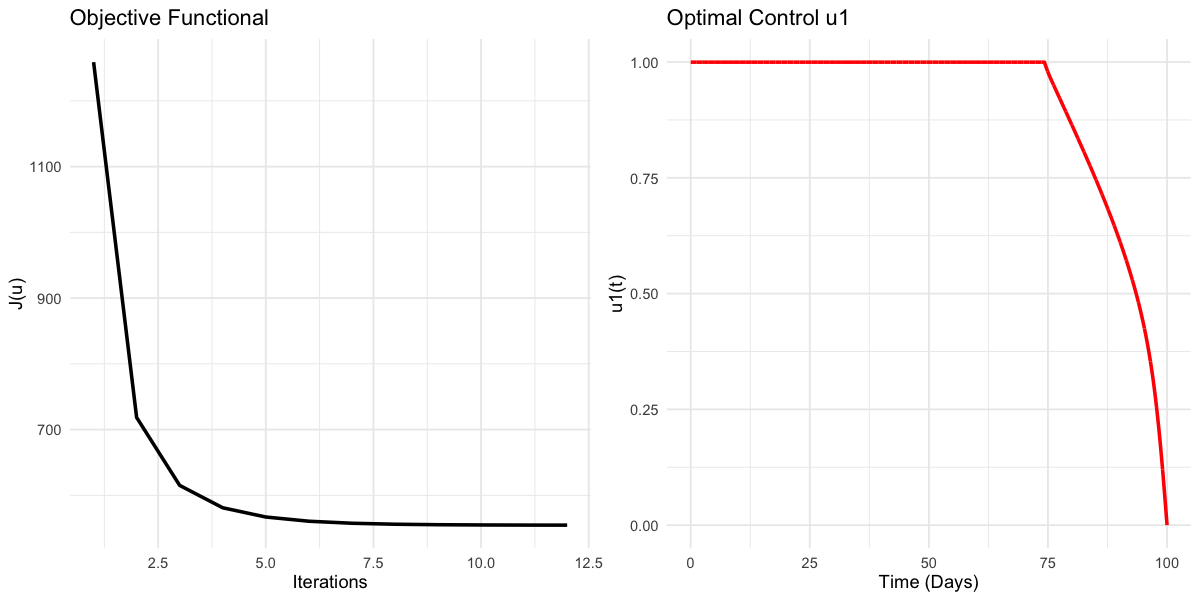

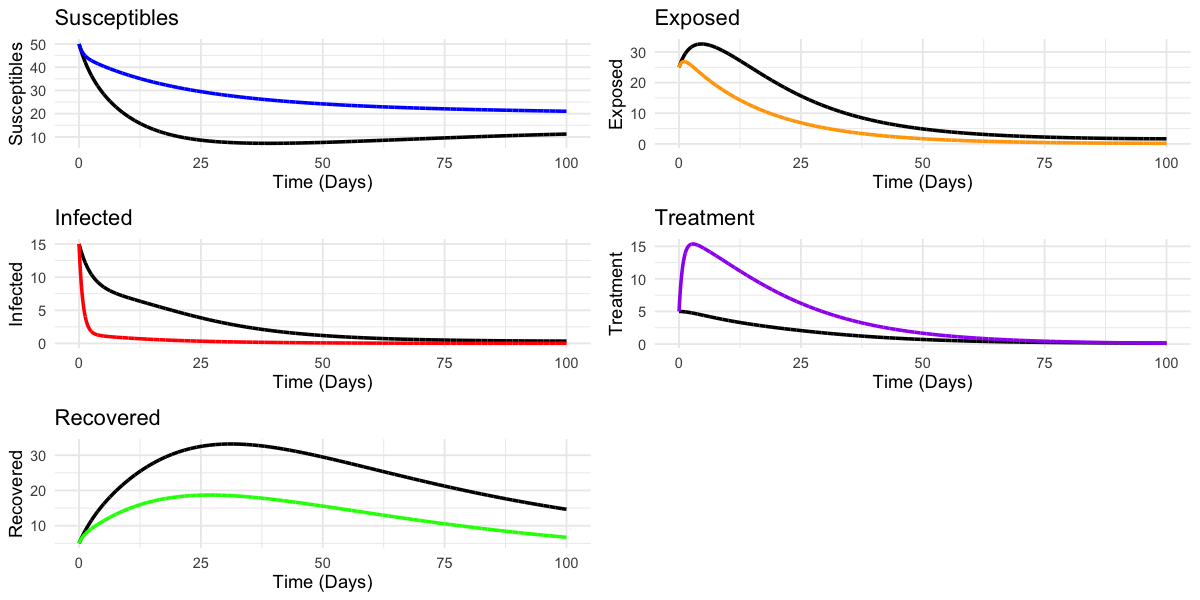

In [5]:
plot_ode_results(ode_sol)

## C++ Kernel Validation

Quick sanity check with each network type.

In [6]:
# ============================================================================
# VALIDATION: Test C++ kernel with all three network types
# ============================================================================

u1_test <- rep(0.03, t_max + 1)

for (net in c('ER', 'BA', 'WS')) {
  par1 <- if (net == 'WS') 0.3 else if (net == 'BA') 0.05 else 0.5
  par2 <- if (net == 'WS') 4L else 10L

  res <- run_seitr_simulation_cpp(
    network_type_str = net, n = n, n_par1 = par1, n_par2 = par2,
    Lambda = Lambda, beta1 = beta1, beta2 = beta2, beta3 = beta3,
    alpha1 = alpha1, alpha2 = alpha2, delta_I = delta_I, delta_T = delta_T,
    mu = mu, init_S = init_S, init_E = init_E, init_I = init_I,
    init_T = init_T, init_R = init_R,
    t_max = t_max, u1_profile = u1_test, num_exp = 3L, w1 = w1
  )
  cat(net, '- Final S/E/I/T/R:',
      round(tail(res$avg$S,1),1), '/',
      round(tail(res$avg$E,1),1), '/',
      round(tail(res$avg$I,1),1), '/',
      round(tail(res$avg$T,1),1), '/',
      round(tail(res$avg$R,1),1), '\n')
}
cat('All network types validated.\n')

ER - Final S/E/I/T/R: 13.7 / 0.7 / 0 / 0.3 / 11.3 
BA - Final S/E/I/T/R: 21.3 / 0 / 0 / 0 / 7.7 
WS - Final S/E/I/T/R: 25.3 / 0 / 0 / 0 / 7 
All network types validated.


## Experiment API Demonstration

The `run_experiment()` function supports multiple modes:

1. **Optimization mode**: supply `K` to run multi-start L-BFGS-B
2. **Forward-only mode**: supply `u1_profile` to skip optimization
3. **No-control flag**: set `run_no_control = TRUE/FALSE`

This lets you run any experiment independently without re-running others.

In [7]:
# ============================================================================
# EXAMPLE: Run a single optimization experiment (ER, p=0.5, K=5)
# ============================================================================

K_ex <- 5
ode_guess_ex <- get_ode_initial_guess(ode_sol$u1, ode_sol$time, t_max, K_ex, dt)

exp_example <- do.call(run_experiment, c(
  list(network_type = 'ER', n = n, n_par1 = 0.5, n_par2 = 10L,
       K = K_ex, n_starts = 10, n_cores = n_cores,
       ode_init_guess = ode_guess_ex),
  shared_args
))

=== Experiment: ER n= 100 par1= 0.5 K= 5 ===
Setting up parallel cluster with 16 cores...
  Start 1 / 10 : ODE warm-start
    -> J = 404.0674 
  Start 2 / 10 : random init
    -> J = 493.0071 
  Start 3 / 10 : random init
    -> J = 516.5358 
  Start 4 / 10 : random init
    -> J = 503.7897 
  Start 5 / 10 : random init
    -> J = 476.4596 
  Start 6 / 10 : random init
    -> J = 596.3175 
  Start 7 / 10 : random init
    -> J = 403.7415 
  Start 8 / 10 : random init
    -> J = 474.5856 
  Start 9 / 10 : random init
    -> J = 430.0621 
  Start 10 / 10 : random init
    -> J = 514.209 
Best start: 7 with J = 403.7415 
Running forward simulation ( 20 replicates)...
Running no-control baseline ( 20 replicates)...
  Optimizer J  = 403.7415 
  Forward J    = 446.328 
  No-control J = 917.895 
=== Done ===



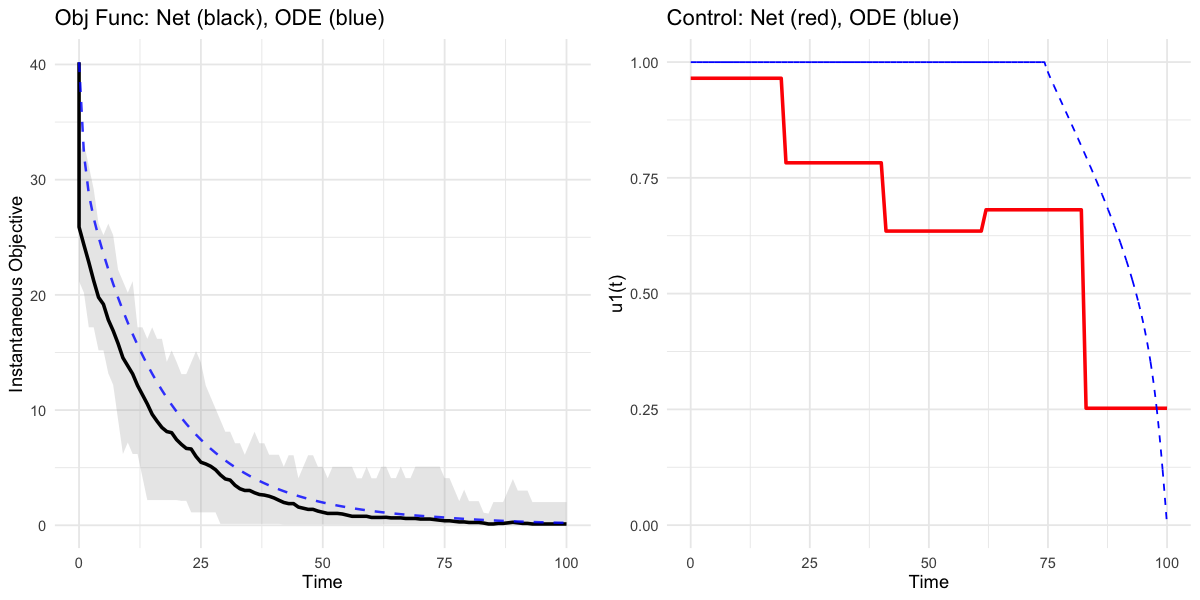

Optimizer-reported J: 403.7415 
Forward check J:     446.328 
No-control J:        917.895 


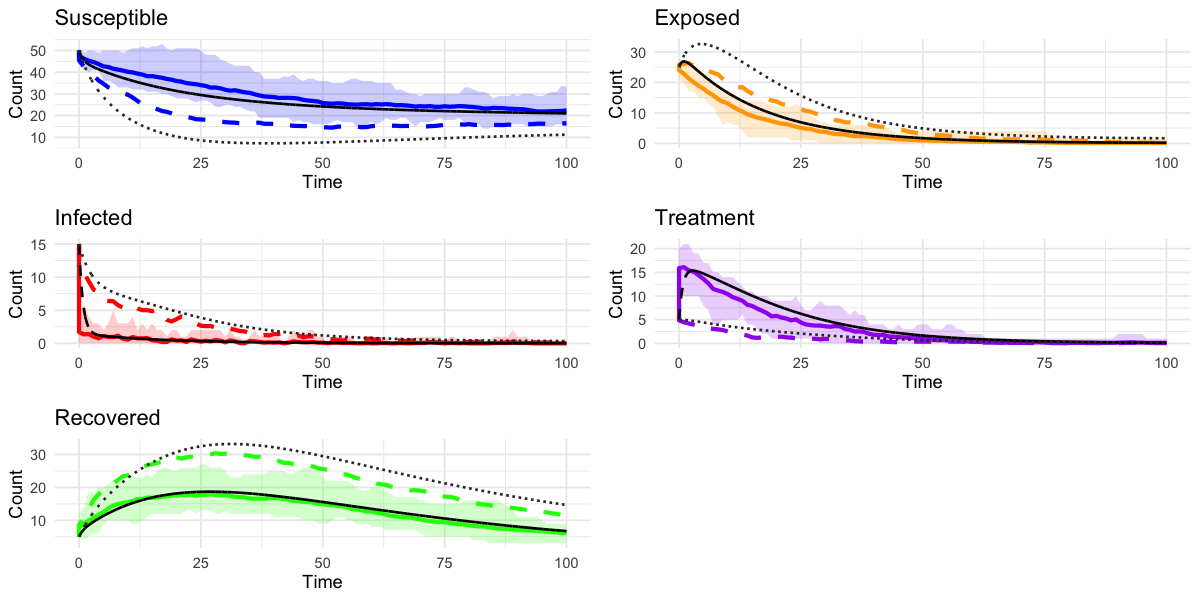

In [8]:
plot_experiment_diagnostics(exp_example, ode_sol, w1)

In [9]:
# ============================================================================
# EXAMPLE: Forward-only mode (reuse the optimized control from above)
# This demonstrates running a forward simulation without re-optimizing.
# ============================================================================

exp_forward_only <- do.call(run_experiment, c(
  list(network_type = 'ER', n = n, n_par1 = 0.5, n_par2 = 10L,
       u1_profile = exp_example$u1_profile,
       num_exp_forward = 40L,
       run_no_control = FALSE),
  shared_args
))

cat('Forward J (40 reps):', round(exp_forward_only$J_opt$J_total, 4), '\n')

=== Experiment: ER n= 100 par1= 0.5 ===
Running forward simulation ( 40 replicates)...
  Forward J    = 455.6835 
=== Done ===

Forward J (40 reps): 455.6835 


## Experiment Grid

Each experiment below can be run independently. The grid covers:
- **ER networks**: p = 0.2, 0.5, 0.9 (Chapter 2 configurations)
- **K values**: 5, 10, 12, 20, 25, 50, 100

For Chapter 3, uncomment the BA and WS sections to extend the sweep.
Results are accumulated into a summary table.

In [10]:
# ============================================================================
# EXPERIMENT GRID
#
# Each (network_type, connectivity, K) combination runs independently.
# Results are stored in a named list and summarized at the end.
# ============================================================================

K_values <- c(5, 50)

# Network configurations: each is a list(type, par1, par2, label)
network_configs <- list(
  # --- ER networks (Chapter 2) ---
  list(type = 'ER', par1 = 0.2, par2 = 10L, label = 'ER_p02'),
  list(type = 'ER', par1 = 0.5, par2 = 10L, label = 'ER_p05'),
  list(type = 'ER', par1 = 0.9, par2 = 10L, label = 'ER_p09')

  # --- BA networks (Chapter 3 — uncomment when ready) ---
  # list(type = 'BA', par1 = 0.03, par2 = 10L, label = 'BA_m3'),
  # list(type = 'BA', par1 = 0.05, par2 = 10L, label = 'BA_m5'),
  # list(type = 'BA', par1 = 0.10, par2 = 10L, label = 'BA_m10')

  # --- WS networks (Chapter 3 — uncomment when ready) ---
  # list(type = 'WS', par1 = 0.1, par2 = 4L,  label = 'WS_p01_k4'),
  # list(type = 'WS', par1 = 0.3, par2 = 4L,  label = 'WS_p03_k4'),
  # list(type = 'WS', par1 = 0.5, par2 = 4L,  label = 'WS_p05_k4')
)

all_experiments <- list()
summary_rows    <- list()

for (nc in network_configs) {
  for (K_val in K_values) {
    exp_name <- paste0('result_', nc$label, '_K', K_val)
    cat('\n>>> Running:', exp_name, '<<<\n')

    ode_guess <- get_ode_initial_guess(ode_sol$u1, ode_sol$time, t_max, K_val, dt)

    exp_out <- tryCatch(
      do.call(run_experiment, c(
        list(network_type = nc$type, n = n,
             n_par1 = nc$par1, n_par2 = nc$par2,
             K = K_val, n_starts = 10, n_cores = n_cores,
             ode_init_guess = ode_guess),
        shared_args
      )),
      error = function(e) {
        cat('ERROR:', e$message, '\n')
        NULL
      }
    )

    if (!is.null(exp_out)) {
      all_experiments[[exp_name]] <- exp_out
      summary_rows[[exp_name]] <- data.frame(
        Name    = exp_name,
        Optim   = round(exp_out$optim_J, 4),
        Forward = round(exp_out$J_opt$J_total, 4),
        Ode     = round(J_ode_total, 4),
        stringsAsFactors = FALSE
      )
    }

    # Checkpoint after each experiment
    saveRDS(all_experiments, 'experiment_results.rds')
  }
}

cat('\n=== All experiments complete ===\n')


>>> Running: result_ER_p02_K5 <<<
=== Experiment: ER n= 100 par1= 0.2 K= 5 ===
Setting up parallel cluster with 16 cores...
  Start 1 / 10 : ODE warm-start
    -> J = 366.9486 
  Start 2 / 10 : random init
    -> J = 396.4459 
  Start 3 / 10 : random init
    -> J = 385.7428 
  Start 4 / 10 : random init
    -> J = 396.4438 
  Start 5 / 10 : random init
    -> J = 396.4427 
  Start 6 / 10 : random init
    -> J = 351.4101 
  Start 7 / 10 : random init
    -> J = 376.3945 
  Start 8 / 10 : random init
    -> J = 385.182 
  Start 9 / 10 : random init
    -> J = 381.5391 
  Start 10 / 10 : random init
    -> J = 351.4064 
Best start: 10 with J = 351.4064 
Running forward simulation ( 20 replicates)...
Running no-control baseline ( 20 replicates)...
  Optimizer J  = 351.4064 
  Forward J    = 387.1124 
  No-control J = 617.1165 
=== Done ===


>>> Running: result_ER_p02_K50 <<<
=== Experiment: ER n= 100 par1= 0.2 K= 50 ===
Setting up parallel cluster with 16 cores...
  Start 1 / 10 : ODE 

## Results Summary Table

In [11]:
# ============================================================================
# RESULTS TABLE
# ============================================================================

if (length(summary_rows) > 0) {
  result_df <- do.call(rbind, summary_rows)
  rownames(result_df) <- NULL

  # Sort by K then by connectivity parameter
  get_K <- function(nm) as.numeric(regmatches(nm, regexpr('(?<=_K)\\d+', nm, perl=TRUE)))
  get_p <- function(nm) {
    m <- regmatches(nm, regexpr('(?<=_p)\\d+', nm, perl=TRUE))
    if (length(m) > 0) as.numeric(m) / 100 else NA
  }
  ord <- order(sapply(result_df$Name, get_K), sapply(result_df$Name, get_p))
  result_df <- result_df[ord, , drop = FALSE]
  rownames(result_df) <- NULL
  print(result_df)
} else {
  cat('No results yet.\n')
}

               Name    Optim  Forward     Ode
1  result_ER_p02_K5 351.4064 387.1124 563.314
2  result_ER_p05_K5 404.0674 463.5169 563.314
3  result_ER_p09_K5 504.1719 520.2594 563.314
4 result_ER_p02_K50 352.4965 399.8350 563.314
5 result_ER_p05_K50 405.0325 435.9370 563.314
6 result_ER_p09_K50 516.1765 522.4630 563.314


## Per-Experiment Diagnostic Plots


--- Plotting: result_ER_p02_K5 ---


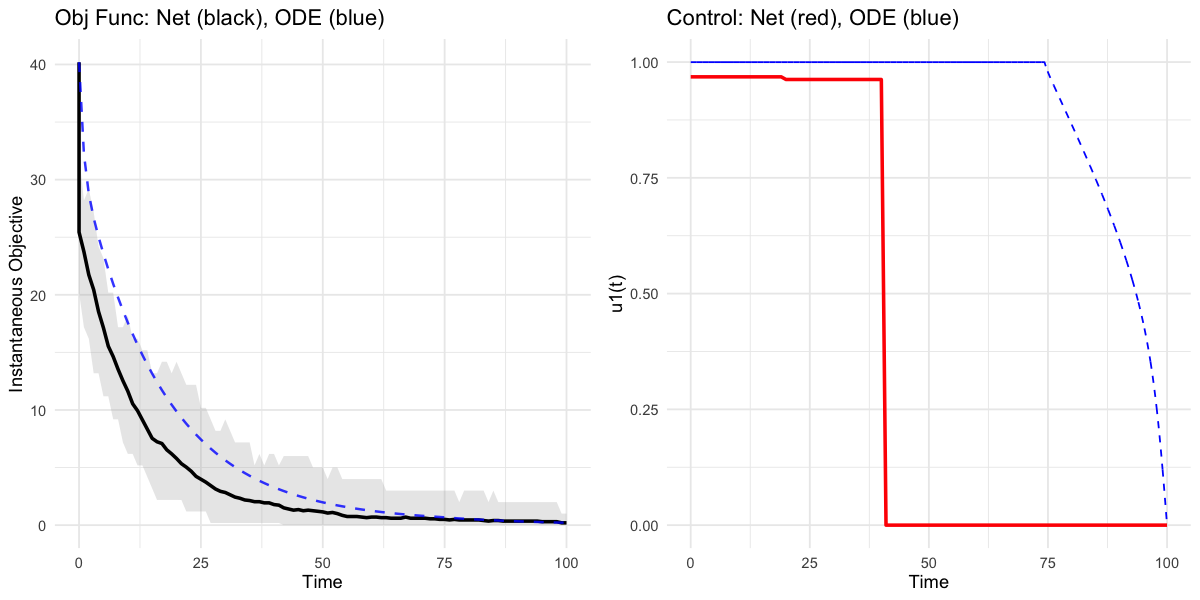

Optimizer-reported J: 351.4064 
Forward check J:     387.1124 
No-control J:        617.1165 

--- Plotting: result_ER_p02_K50 ---


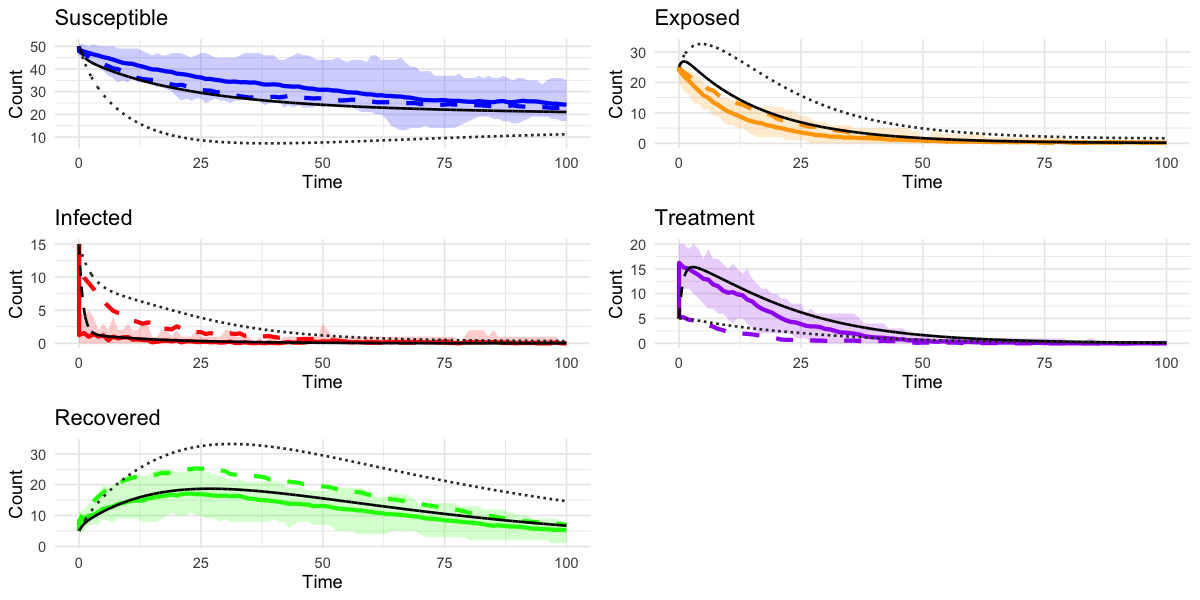

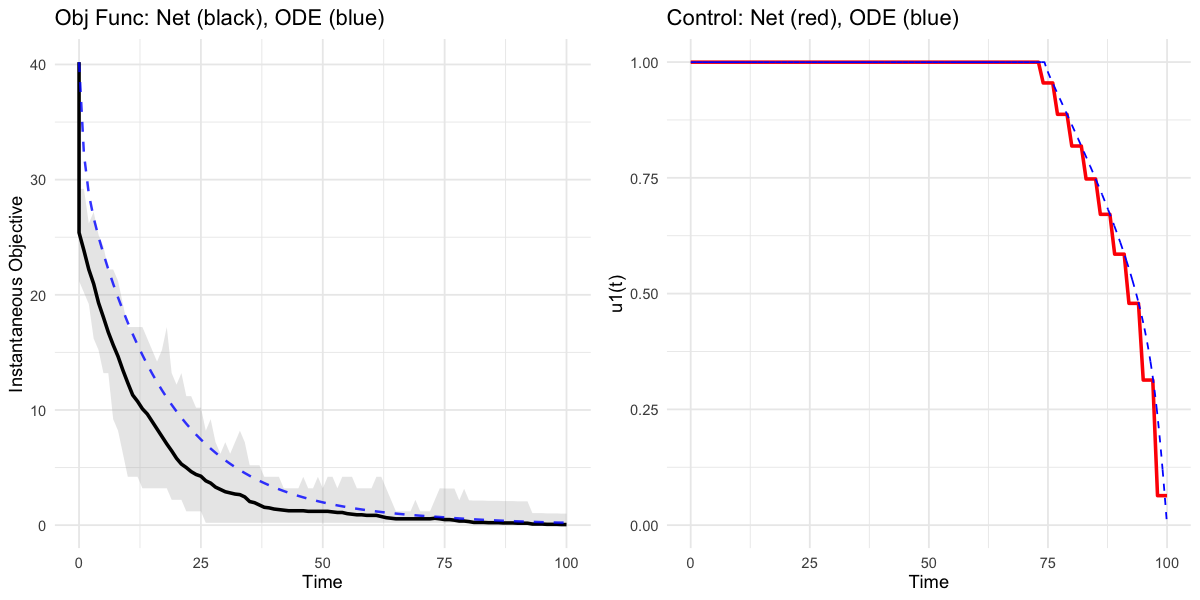

Optimizer-reported J: 352.4965 
Forward check J:     399.835 
No-control J:        650.3145 

--- Plotting: result_ER_p05_K5 ---


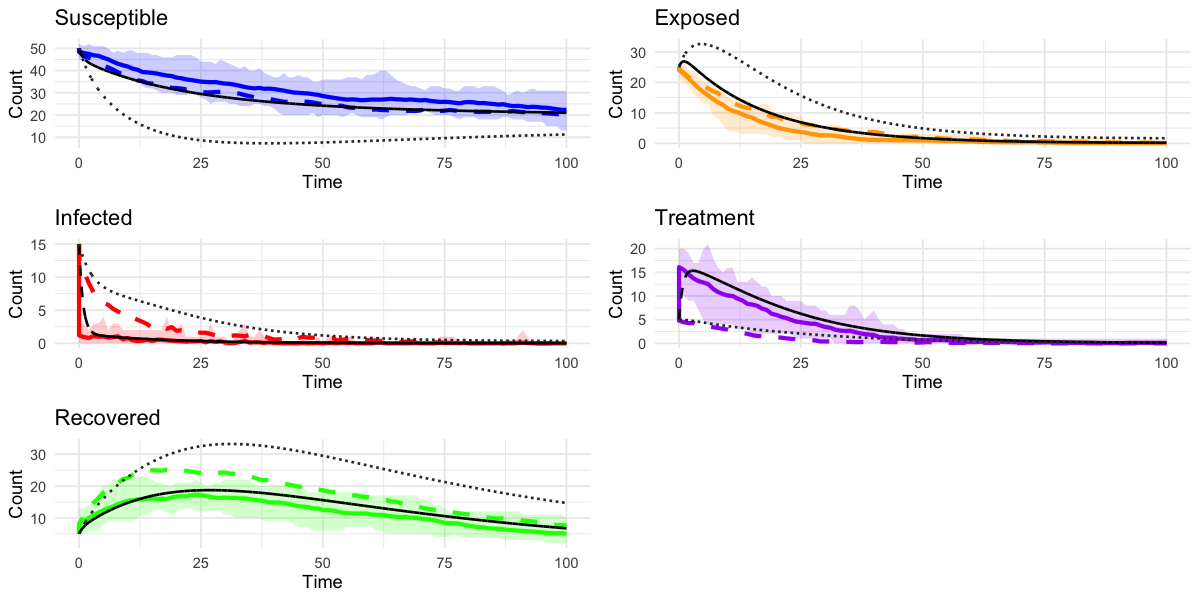

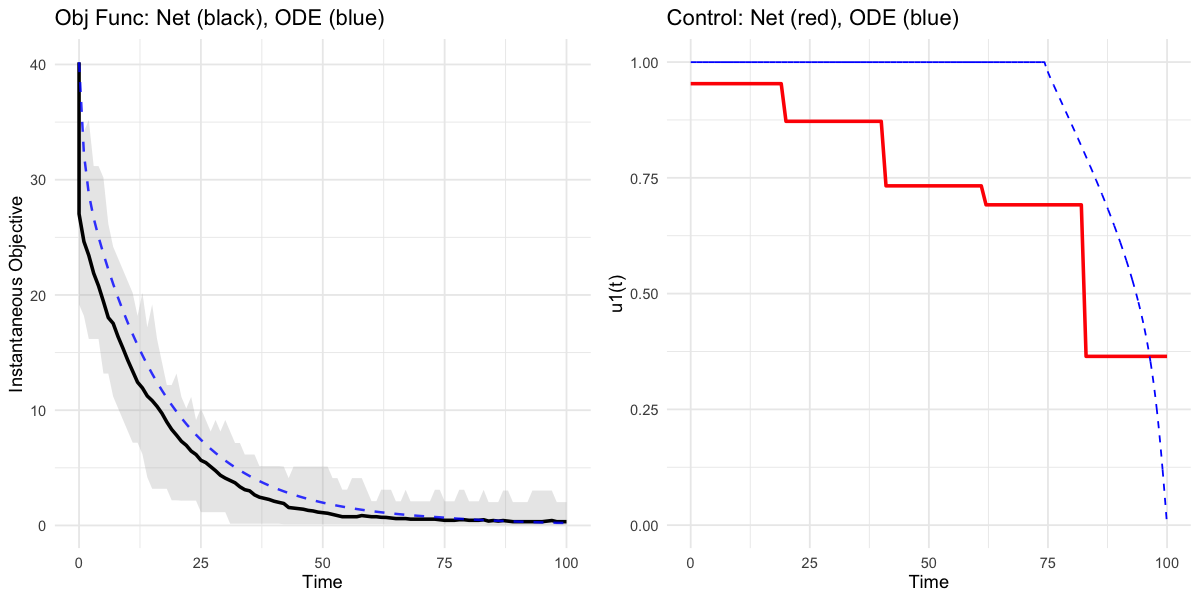

Optimizer-reported J: 404.0674 
Forward check J:     463.5169 
No-control J:        929.709 

--- Plotting: result_ER_p05_K50 ---


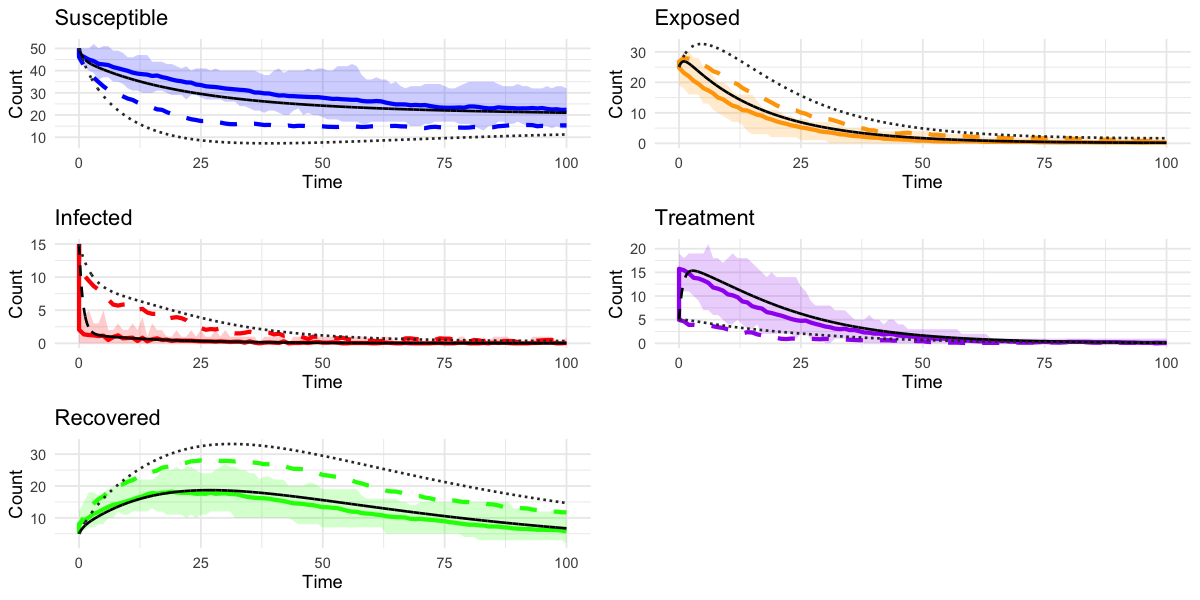

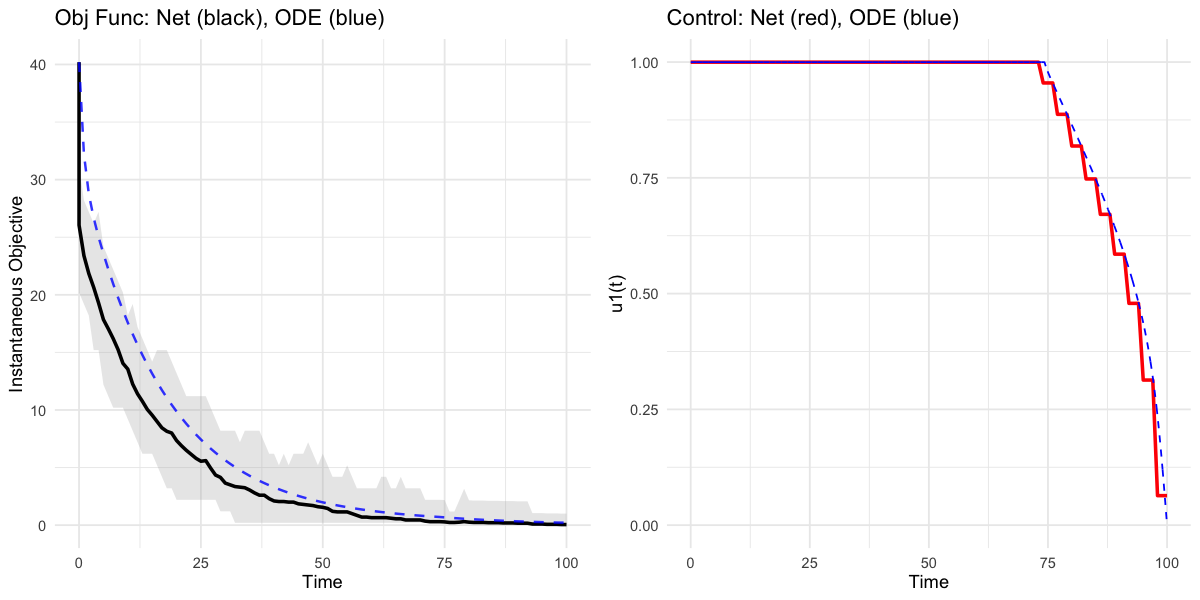

Optimizer-reported J: 405.0325 
Forward check J:     435.937 
No-control J:        988.35 

--- Plotting: result_ER_p09_K5 ---


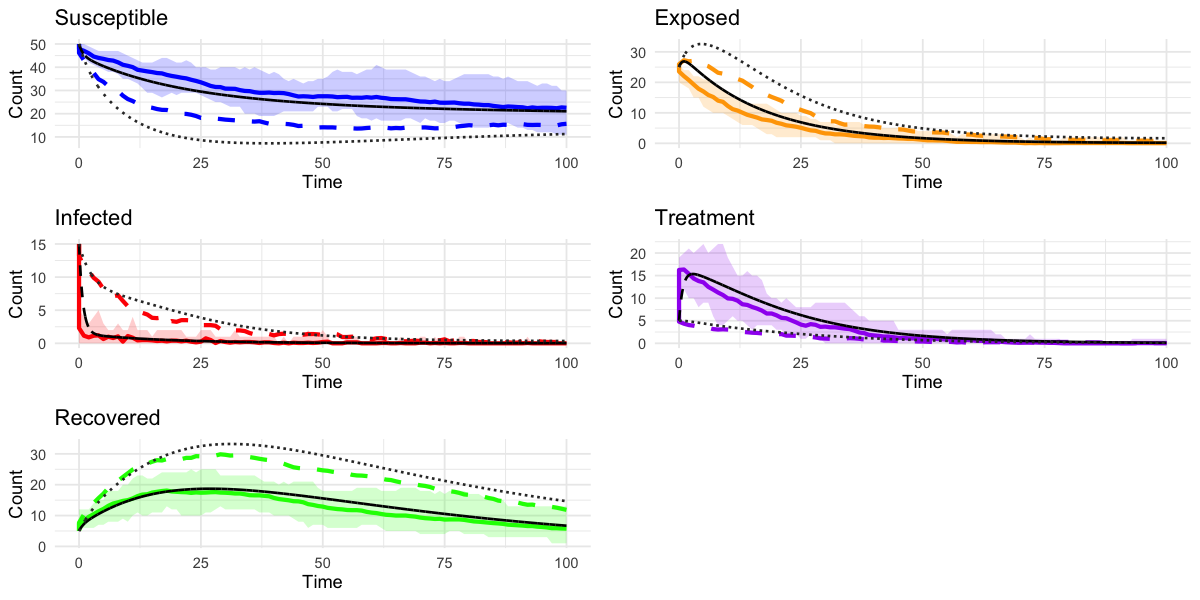

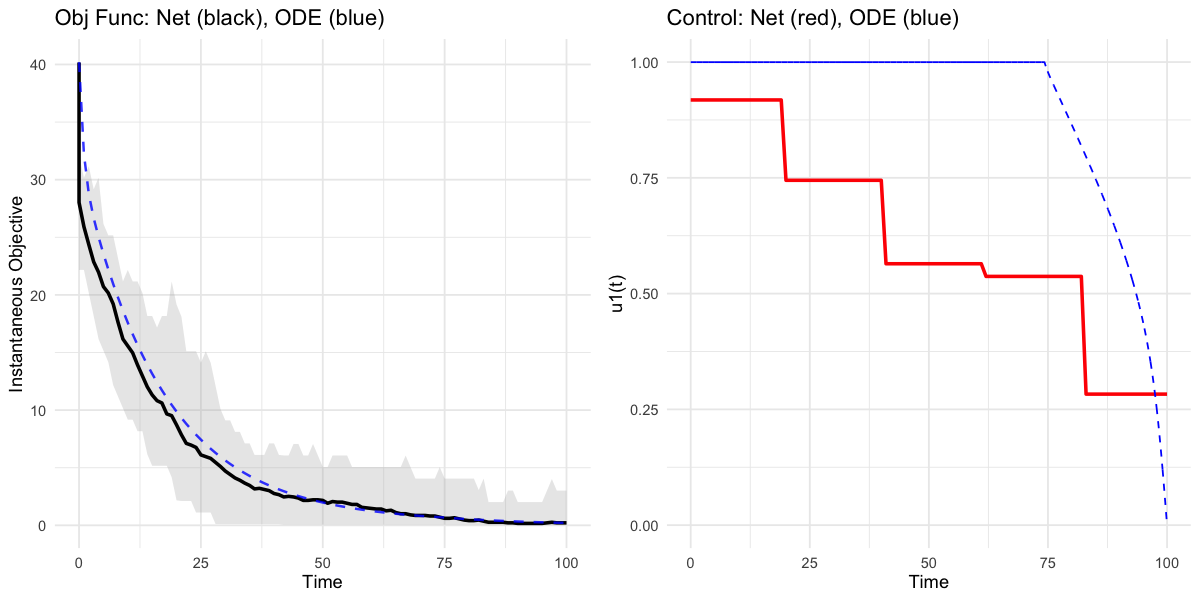

Optimizer-reported J: 504.1719 
Forward check J:     520.2594 
No-control J:        1229.893 

--- Plotting: result_ER_p09_K50 ---


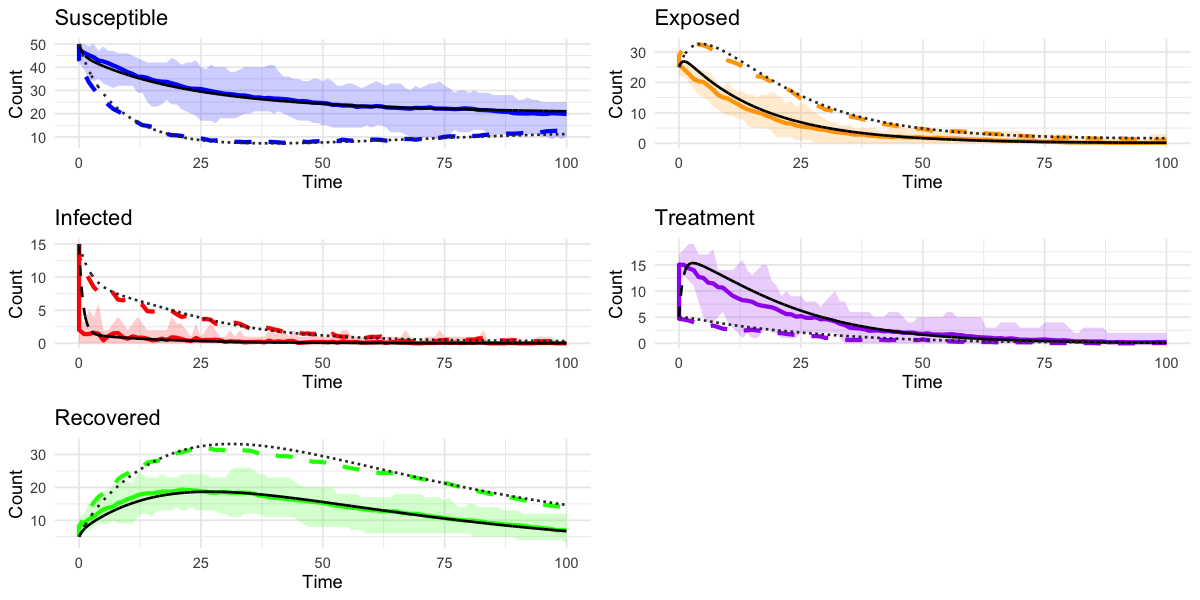

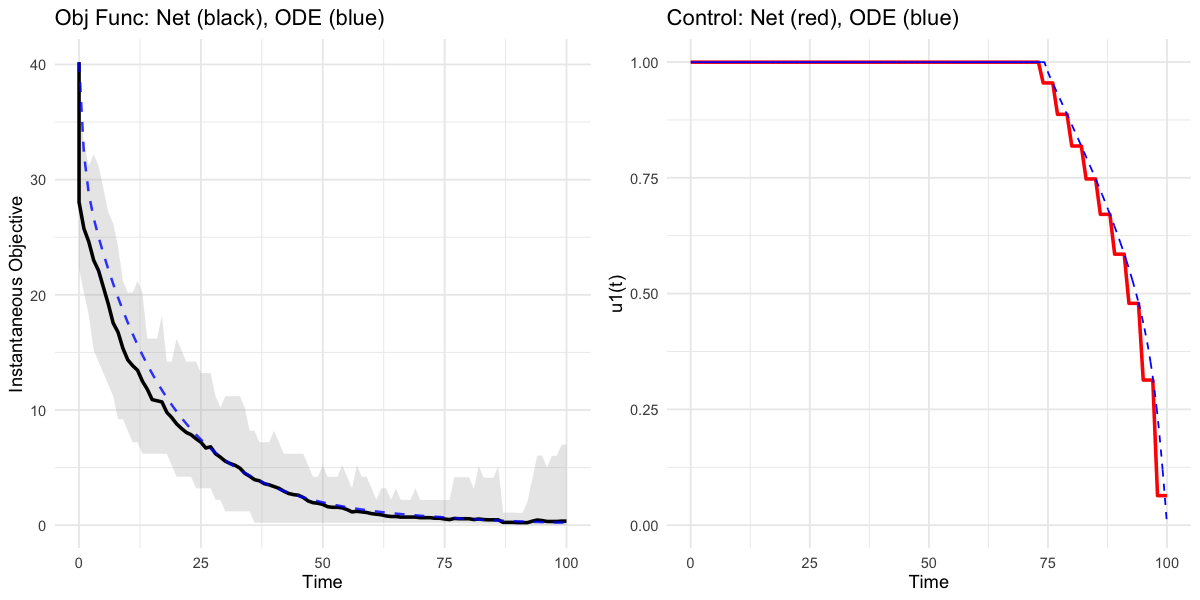

Optimizer-reported J: 516.1765 
Forward check J:     522.463 
No-control J:        1245.8 


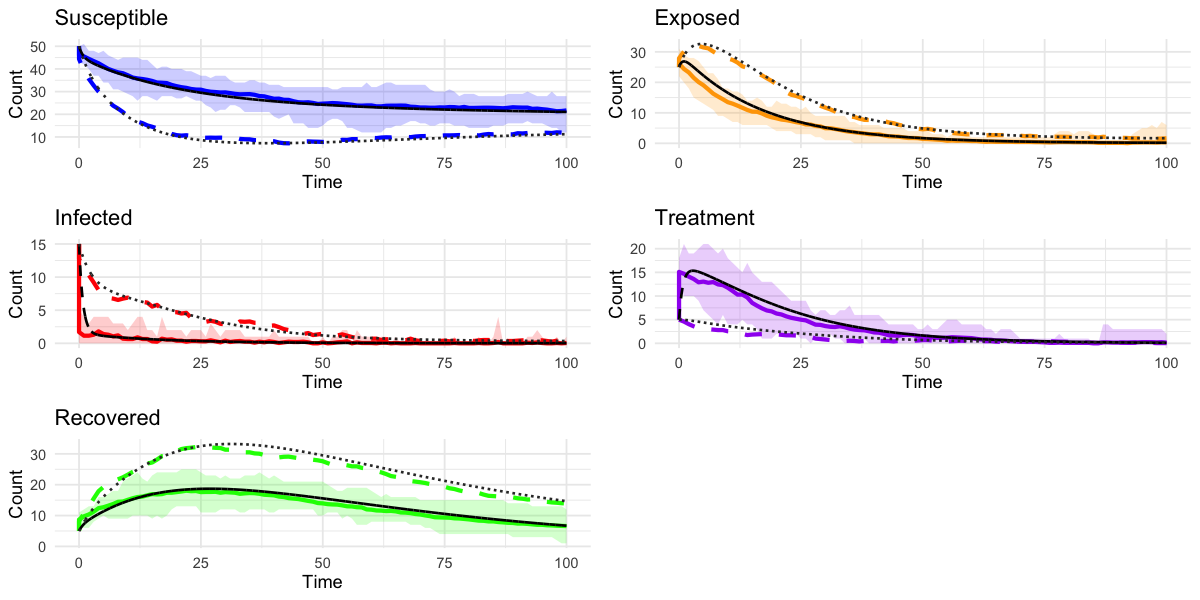

In [12]:
# ============================================================================
# DIAGNOSTIC PLOTS FOR EACH COMPLETED EXPERIMENT
# ============================================================================

for (exp_name in names(all_experiments)) {
  cat('\n--- Plotting:', exp_name, '---\n')
  tryCatch(
    plot_experiment_diagnostics(all_experiments[[exp_name]], ode_sol, w1),
    error = function(e) cat('Plot error:', e$message, '\n')
  )
}

## Standalone Experiment Template

Copy and modify this cell to run any single experiment independently.
No dependency on the grid above.

In [ ]:
# ============================================================================
# STANDALONE EXPERIMENT TEMPLATE
#
# Modify network_type, n_par1, n_par2, and K as needed.
# This cell is self-contained — it can be run without the grid above.
# ============================================================================

# --- Choose experiment parameters ---
my_network <- 'ER'   # 'ER', 'BA', or 'WS'
my_par1    <- 0.5     # ER: edge prob p | BA: attachment param | WS: rewire prob
my_par2    <- 10L     # WS: neighbors per side (ignored for ER/BA)
my_K       <- 5       # Piecewise-constant segments

# --- ODE warm-start ---
my_ode_guess <- get_ode_initial_guess(ode_sol$u1, ode_sol$time, t_max, my_K, dt)

# --- Run ---
my_result <- do.call(run_experiment, c(
  list(network_type = my_network, n = n,
       n_par1 = my_par1, n_par2 = my_par2,
       K = my_K, n_starts = 10, n_cores = n_cores,
       ode_init_guess = my_ode_guess),
  shared_args
))

# --- Visualize ---
plot_experiment_diagnostics(my_result, ode_sol, w1)